<a href="https://colab.research.google.com/github/sohailGHUB/Calories_Burnt_Prediction_ML_MODEL/blob/main/ML_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing dependencies




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection and processing


In [ ]:
#loading the data from csv file to a pandas dataframe
calories = pd.read_csv('/content/calories.csv')

In [ ]:
#print the first five rows of dataframe
calories.head()

,User_ID,Calories
0,14733363,231
1,14861698,66
2,11179863,26
3,16180408,71
4,17771927,35


In [ ]:
exercise_data = pd.read_csv('/content/exercise.csv')

In [ ]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190,94,29,105,40.8
1,14861698,female,20,166,60,14,94,40.3
2,11179863,male,69,179,79,5,88,38.7
3,16180408,female,34,179,71,13,100,40.5
4,17771927,female,27,154,58,10,81,39.8


In [ ]:
 # combining the two data frames
 calories_data = pd.concat([exercise_data,calories['Calories']],axis=1)
#axis=0 means adding data row wise, =1 means adding column wise

In [ ]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190,94,29,105,40.8,231
1,14861698,female,20,166,60,14,94,40.3,66
2,11179863,male,69,179,79,5,88,38.7,26
3,16180408,female,34,179,71,13,100,40.5,71
4,17771927,female,27,154,58,10,81,39.8,35


In [ ]:
#data frame has 15000 rows and 9 cols (good size i,e sample of 15000 people)
calories_data.shape

(15000, 9)

In [ ]:
#getting some more info about the data frame
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  int64  
 4   Weight      15000 non-null  int64  
 5   Duration    15000 non-null  int64  
 6   Heart_Rate  15000 non-null  int64  
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 1.0+ MB


In [ ]:
#checking for missing values
calories_data.isnull().sum()
# there are no missing values , if missing values are there then we have to
# process the data (clean) hence no preprocessing is required here


User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Data Analysis

In [ ]:
#get some statistical info about the dataset
calories_data.describe()
#std = standard deviation, min = min value of column,

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Data Visualization


In [ ]:
 sns.set()

<Axes: xlabel='count', ylabel='Gender'>

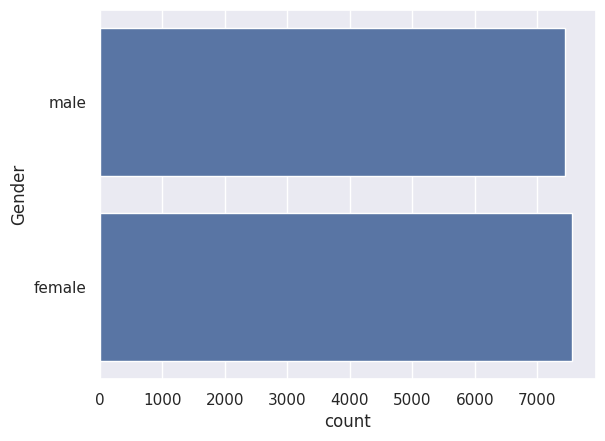

In [ ]:
 #plotting gender column in count plot
 sns.countplot(calories_data['Gender'])
 #almost eaual males and females , its a well distributed dataset
 #gender is a categorical type rest are all distribution type

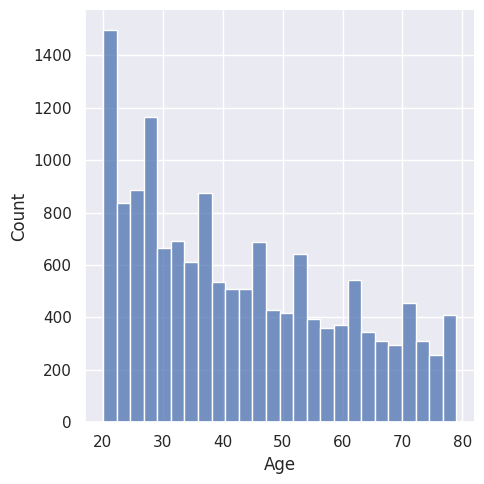

In [ ]:
#finding distribution of age column
sns.displot(calories_data['Age'])

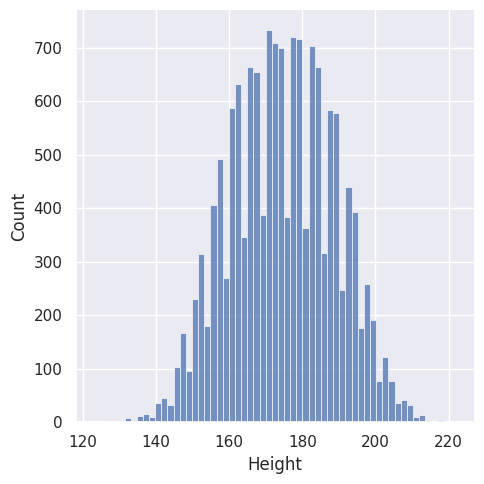

In [ ]:
#for height
sns.displot(calories_data['Height'])

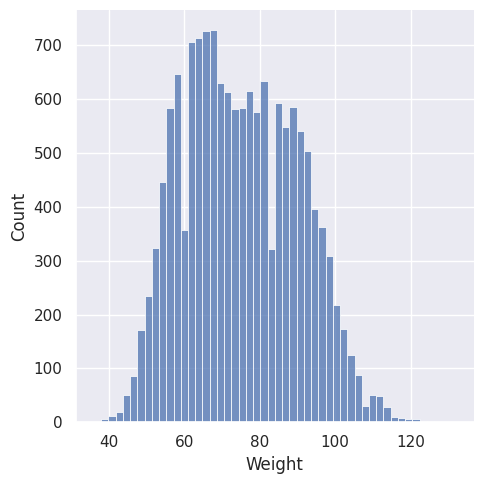

In [ ]:
#for weight
sns.displot(calories_data['Weight'])


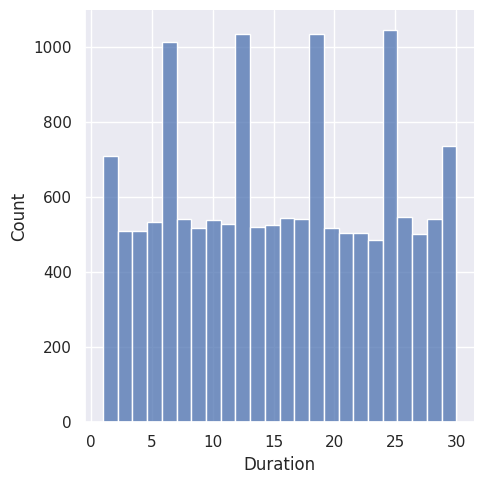

In [ ]:
sns.displot(calories_data['Duration'])

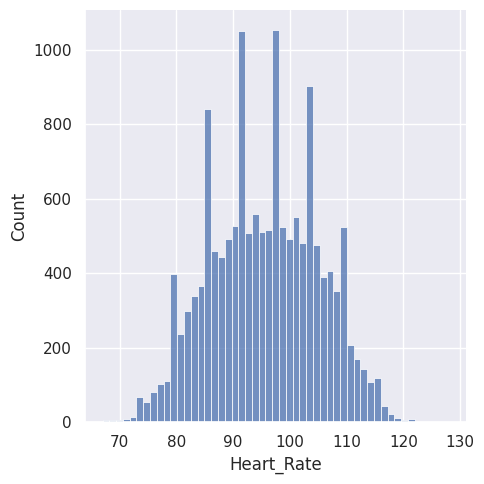

In [ ]:
sns.displot(calories_data['Heart_Rate'])

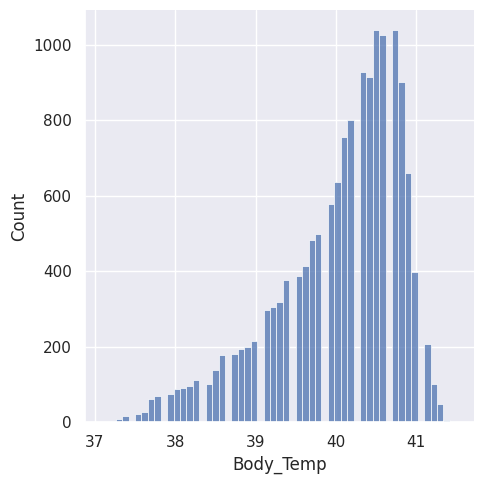

In [ ]:
sns.displot(calories_data['Body_Temp'])

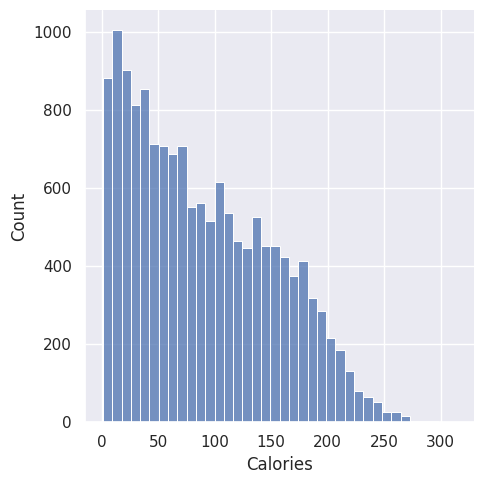

In [ ]:
sns.displot(calories_data['Calories'])

Finding Correlation in Dataset

converting text data #gender to numerical value

In [ ]:
calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)

In [ ]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190,94,29,105,40.8,231
1,14861698,1,20,166,60,14,94,40.3,66
2,11179863,0,69,179,79,5,88,38.7,26
3,16180408,1,34,179,71,13,100,40.5,71
4,17771927,1,27,154,58,10,81,39.8,35


In [ ]:
# Calculate correlation matrix
correlation_matrix = calories_data.corr()



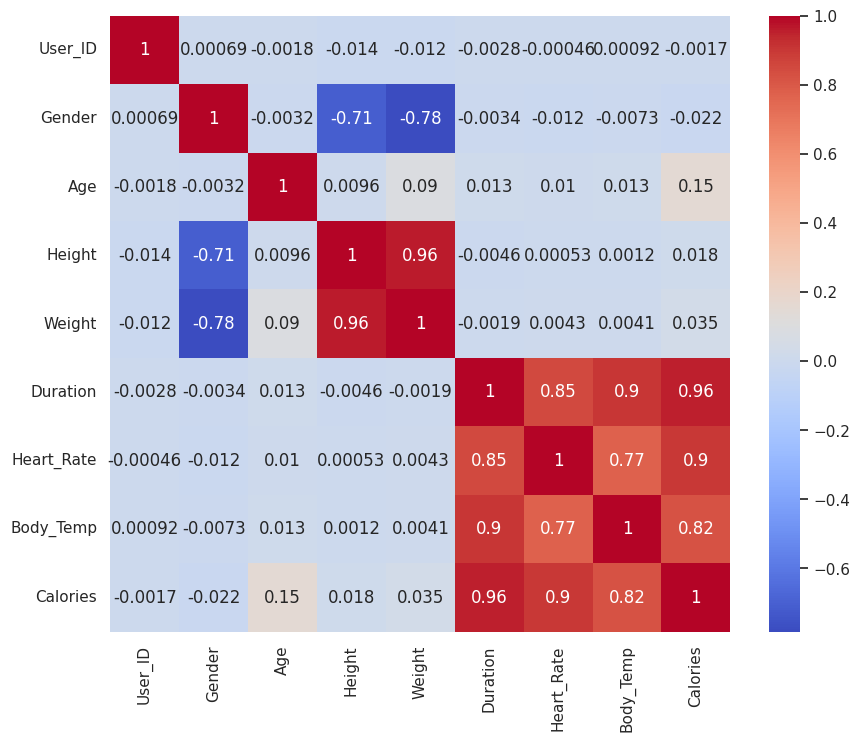

In [ ]:
# Visualize the correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

separating features and  target

In [ ]:
X = calories_data.drop(columns=['User_ID','Calories'],axis=1)
Y = calories_data['Calories']
#this means all columns except user ID and calories are stored in x, and calories in Y

In [ ]:
X

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,68,190,94,29,105,40.8
1,1,20,166,60,14,94,40.3
2,0,69,179,79,5,88,38.7
3,1,34,179,71,13,100,40.5
4,1,27,154,58,10,81,39.8
...,...,...,...,...,...,...,...
14995,1,20,193,86,11,92,40.4
14996,1,27,165,65,6,85,39.2
14997,1,43,159,58,16,90,40.1
14998,0,78,193,97,2,84,38.3


In [ ]:
Y

0        231
1         66
2         26
3         71
4         35
        ... 
14995     45
14996     23
14997     75
14998     11
14999     98
Name: Calories, Length: 15000, dtype: int64

splitting the data into training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
#the x is separated into x_train and X_test and similarly Y

In [ ]:
print(X.shape, X_train.shape, X_test.shape)
#original x has 15k rows and 7 cols which is now splitted as 1.xtrain=12k rows and 7cols, 2.3k rows and 7cols (note that test is 20% of whole since testsize=0.2 above)

(15000, 7) (12000, 7) (3000, 7)


In [ ]:
X_test

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
7592,1,41,172,74,24,98,40.8
3551,0,70,189,96,24,113,40.9
9698,1,53,173,68,7,96,39.3
3759,0,36,191,96,2,82,38.4
2353,1,46,169,68,20,111,40.6
...,...,...,...,...,...,...,...
8859,1,20,161,60,29,107,40.3
2886,1,40,152,49,11,87,39.8
14357,1,57,160,62,23,103,40.2
9430,1,58,171,67,6,82,39.4


In [ ]:
X_train

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
1154,1,38,169,67,3,85,38.5
9804,0,30,194,96,9,91,39.6
7919,1,78,182,79,7,84,39.4
4854,0,50,171,77,29,111,40.8
5947,1,32,172,66,29,105,40.8
...,...,...,...,...,...,...,...
11798,1,49,178,71,12,98,39.9
13896,1,67,159,58,23,101,40.4
6637,1,25,167,64,20,100,40.4
2575,1,36,167,64,28,108,40.8


Training the model

XGBoost Regressor

In [ ]:
#loading the model XGB
model = XGBRegressor()


In [ ]:
#train the model with x_train
#as we know xtrain is the fearures data, and ytrain is the calories model.fit() function helps the model to get trained
#whwn we give this data x_train , Y_train to xgb regressor model , it finds the pattern bw the data such as if duration is more than the calories will be more and if the heartrate is more then the calories will be more,
model.fit(X_train,Y_train)
#now our model has trained

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Evaluation of model

test data prediction


In [ ]:
test_data_prediction = model.predict(X_test)
#X_test is the features data

In [ ]:
test_data_prediction
#we have trained the model and it has predicted the values for the x_test data

array([125.58828 , 222.11377 ,  38.725952, ..., 144.3179  ,  23.425894,
        90.100494], dtype=float32)

In [ ]:
test_data_prediction.shape
#since the test data has 3000 rows

(3000,)

Mean absolute error

In [ ]:
#lets say the calories value is 130 , but our model predicted 125.58 approx 125 so 5 is the error which our model is making
# so we find th error for all the values and take the average of all error values . this is the overall error which our model is making this is called mean absolut error
MAE = metrics.mean_absolute_error(Y_test,test_data_prediction)
print("Mean Absolute Error = ", MAE)#we taking y_test since we are bothered about calories

Mean Absolute Error =  1.4833678883314132


In [ ]:
#MAE is 1.48 that means if the real value is 130 our model is predicting 128.5 which is very less error
'''Separating data into training and testing sets is a fundamental concept in machine learning, and it's crucial for building robust and generalizable models. Here's why:

Training Data:

- Used to train the model, i.e., to learn patterns and relationships within the data.
- The model sees this data and adjusts its parameters to fit the data well.

Testing Data (or Validation Data):

- Used to evaluate the model's performance on unseen data.
- This data is not seen by the model during training, so it's a new, independent dataset.
- It helps estimate how well the model will perform on real-world data, which it hasn't seen before.

By separating data into training and testing sets, you can:

1. Avoid overfitting: When a model is too complex and performs exceptionally well on the training data but poorly on new data.
2. Evaluate model performance: Get an unbiased estimate of how well the model will perform in real-world scenarios.
3. Tune hyperparameters: Use the testing data to adjust hyperparameters and optimize the model's performance.
4. Ensure generalization: Verify that the model can generalize well to new, unseen data.

Typically, a split of 70-80% for training and 20-30% for testing is used, but this ratio can vary depending on the dataset size and complexity'''


"Separating data into training and testing sets is a fundamental concept in machine learning, and it's crucial for building robust and generalizable models. Here's why:\n\nTraining Data:\n\n- Used to train the model, i.e., to learn patterns and relationships within the data.\n- The model sees this data and adjusts its parameters to fit the data well.\n\nTesting Data (or Validation Data):\n\n- Used to evaluate the model's performance on unseen data.\n- This data is not seen by the model during training, so it's a new, independent dataset.\n- It helps estimate how well the model will perform on real-world data, which it hasn't seen before.\n\nBy separating data into training and testing sets, you can:\n\n1. Avoid overfitting: When a model is too complex and performs exceptionally well on the training data but poorly on new data.\n2. Evaluate model performance: Get an unbiased estimate of how well the model will perform in real-world scenarios.\n3. Tune hyperparameters: Use the testing da

Building a System which can predict the calories based on the given input